# 03. Моделирование

В этом ноутбуке:
- загружаем предобработанный датасет;
- делаем разбиение на train / val / test по поездкам;
- обучаем baseline-модель для предсказания класса манёвра;
- оцениваем качество по основным метрикам и смотрим на переобучение.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Загрузка предобработанного датасета

Здесь загружаем файл `telemetry_preprocessed.parquet`,
подготовленный на этапе предобработки.

In [2]:
PROCESSED_PATH = Path("../data/processed/telemetry_preprocessed.parquet")

df = pd.read_parquet(PROCESSED_PATH)
print("df shape:", df.shape)
df.head()

df shape: (2520378, 9)


,t,speed,steering_angle,car_accel,gas,brake,rpm,trip,maneuver_class
0,0.00,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
1,0.01,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
2,0.02,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
3,0.03,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right
4,0.04,0.0,80.0,0.0,0.0,63872.0,0.0,2016-01-30--11-24-51,turn_right


## Разбиение на train / validation / test по поездкам

Важно: поездки (`trip`) не должны пересекаться между выборками,
поэтому используем `GroupShuffleSplit` по признаку `trip`.
А сначала отделяем целевую переменную `maneuver_class`.

In [3]:
target_col = "maneuver_class"
group_col = "trip"

y = df[target_col]
groups = df[group_col]

# признаки — все числовые колонки, кроме target и trip
feature_cols = [
    c for c in df.columns
    if c not in [target_col, group_col]
       and pd.api.types.is_numeric_dtype(df[c])
]

X = df[feature_cols]

X.shape, y.shape

((2520378, 7), (2520378,))

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

train_idx, temp_idx = next(gss.split(X, y, groups))
X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
y_train, y_temp = y.iloc[train_idx], y.iloc[temp_idx]
groups_temp = groups.iloc[temp_idx]

print("Train size:", X_train.shape[0])
print("Temp size:", X_temp.shape[0])

Train size: 1554547
Temp size: 965831


In [5]:
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)

val_idx, test_idx = next(gss_val_test.split(X_temp, y_temp, groups_temp))
X_val, X_test = X_temp.iloc[val_idx], X_temp.iloc[test_idx]
y_val, y_test = y_temp.iloc[val_idx], y_temp.iloc[test_idx]

print("Train:", X_train.shape[0])
print("Val:", X_val.shape[0])
print("Test:", X_test.shape[0])

Train: 1554547
Val: 463693
Test: 502138


In [6]:
train_trips = set(df.iloc[train_idx][group_col])
val_trips   = set(X_val.index.map(df[group_col].iloc.__getitem__))
test_trips  = set(X_test.index.map(df[group_col].iloc.__getitem__))

print("Пересеч train/val:", train_trips & val_trips)
print("Пересеч train/test:", train_trips & test_trips)
print("Пересеч val/test:", val_trips & test_trips)

Пересеч train/val: set()
Пересеч train/test: set()
Пересеч val/test: set()


## Baseline-модель: логистическая регрессия

В качестве первой, простой модели берем многоклассовую
логистическую регрессию. Это линейная модель, которая задаёт
базовый уровень качества, с которым будет идти сравнение.

In [7]:
log_reg = LogisticRegression(
    max_iter=2000
)

log_reg.fit(X_train, y_train)

y_val_pred = log_reg.predict(X_val)
y_test_pred = log_reg.predict(X_test)

print("=== Validation ===")
print(classification_report(y_val, y_val_pred))

print("=== Test ===")
print(classification_report(y_test, y_test_pred))

/Users/ivank/PycharmProjects/commaai/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Validation ===
              precision    recall  f1-score   support

    straight       0.99      1.00      1.00    175533
   turn_left       1.00      1.00      1.00    124019
  turn_right       1.00      1.00      1.00    164141

    accuracy                           1.00    463693
   macro avg       1.00      1.00      1.00    463693
weighted avg       1.00      1.00      1.00    463693

=== Test ===
              precision    recall  f1-score   support

    straight       0.99      1.00      1.00    186456
   turn_left       1.00      0.99      1.00    215250
  turn_right       1.00      1.00      1.00    100432

    accuracy                           1.00    502138
   macro avg       1.00      1.00      1.00    502138
weighted avg       1.00      1.00      1.00    502138



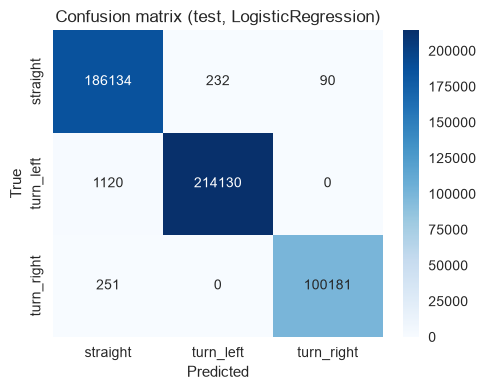

In [8]:
cm = confusion_matrix(y_test, y_test_pred, labels=log_reg.classes_)
cm_df = pd.DataFrame(cm, index=log_reg.classes_, columns=log_reg.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test, LogisticRegression)")
plt.tight_layout()
plt.show()

## Модель RandomForest

Для сравнения берем ансамблевую модель `RandomForestClassifier` из курса.
Она умеет учитывать нелинейные зависимости и взаимодействия признаков.
Сравниваем её качество с логистической регрессией по тем же метрикам.

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_val_pred_rf = rf.predict(X_val)
y_test_pred_rf = rf.predict(X_test)

print("=== Validation (RandomForest) ===")
print(classification_report(y_val, y_val_pred_rf))

print("=== Test (RandomForest) ===")
print(classification_report(y_test, y_test_pred_rf))

=== Validation (RandomForest) ===
              precision    recall  f1-score   support

    straight       1.00      1.00      1.00    175533
   turn_left       1.00      1.00      1.00    124019
  turn_right       1.00      1.00      1.00    164141

    accuracy                           1.00    463693
   macro avg       1.00      1.00      1.00    463693
weighted avg       1.00      1.00      1.00    463693

=== Test (RandomForest) ===
              precision    recall  f1-score   support

    straight       1.00      1.00      1.00    186456
   turn_left       1.00      1.00      1.00    215250
  turn_right       1.00      1.00      1.00    100432

    accuracy                           1.00    502138
   macro avg       1.00      1.00      1.00    502138
weighted avg       1.00      1.00      1.00    502138



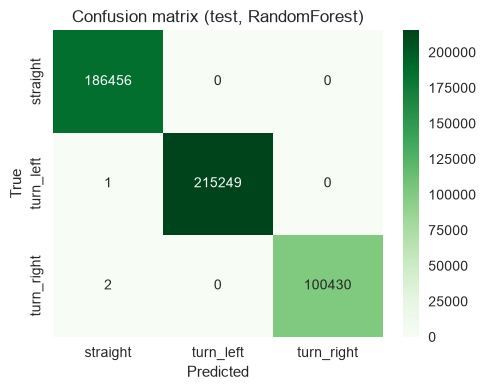

In [10]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=rf.classes_)
cm_rf_df = pd.DataFrame(cm_rf, index=rf.classes_, columns=rf.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf_df, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (test, RandomForest)")
plt.tight_layout()
plt.show()

## Интерпретация confusion-матриц

Ниже сравниваем две модели по confusion-матрицам на тестовой выборке:
логистическую регрессию (baseline) и RandomForest.

### Логистическая регрессия

Для логистической регрессии confusion-матрица показывает:

- класс `straight` в большинстве случаев предсказывается верно, но есть сотни
  ошибок, когда он перепутан с `turn_left` и `turn_right`;
- класс `turn_left` иногда ошибочно классифицируется как `straight`
  (порядка тысячи примеров);
- класс `turn_right` тоже иногда путается со `straight`, но реже.

Главная проблема логистической регрессии — спутывание поворотов с движением
прямо.

При этом модель уже даёт очень высокие значения accuracy и F1 (около 0.99),
поэтому её можно считать сильным baseline.

### RandomForest

Для RandomForest confusion-матрица практически идеально диагональная:

- почти все примеры всех трёх классов попадают на диагональ;
- ошибок классификации всего несколько штук на весь тестовый набор
  (единичные случаи, когда поворот предсказан как `straight`).

Это означает, что RandomForest почти не путает классы и гораздо лучше
разделяет режимы движения автомобиля.

### Вывод

- Логистическая регрессия задаёт высокий базовый уровень качества и показывает,
  что задача хорошо решается даже линейной моделью.
- RandomForest существенно улучшает качество по сравнению с baseline и почти
  полностью устраняет ошибки между классами.
- Поэтому в качестве основной модели для курсового проекта логично выбрать
  RandomForest, а логистическую регрессию использовать как интерпретируемый
  baseline для сравнения.

## Оценка переобучения RandomForest

Чтобы оценить переобучение, сравним качество модели
RandomForest на обучающей и тестовой выборках.
Сильное расхождение метрик будет признаком overfitting.

In [11]:
from sklearn.metrics import accuracy_score

# качество на train
y_train_pred_rf = rf.predict(X_train)
acc_train_rf = accuracy_score(y_train, y_train_pred_rf)

# качество на test (уже есть предсказания y_test_pred_rf)
acc_test_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"RandomForest accuracy train: {acc_train_rf:.4f}")
print(f"RandomForest accuracy test : {acc_test_rf:.4f}")

RandomForest accuracy train: 1.0000
RandomForest accuracy test : 1.0000


## Влияние глубины деревьев на переобучение

Для иллюстрации борьбы с переобучением сравним несколько
вариантов RandomForest с разной максимальной глубиной деревьев
`max_depth` и увидим, как меняется качество на train и test.

In [12]:
depths = [4, 8, 12, None]  # None = без ограничения глубины
results = []

for depth in depths:
    rf_tmp = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        n_jobs=-1,
        random_state=42
    )
    rf_tmp.fit(X_train, y_train)

    y_train_pred = rf_tmp.predict(X_train)
    y_test_pred  = rf_tmp.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test  = accuracy_score(y_test, y_test_pred)

    results.append((depth, acc_train, acc_test))

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "acc_train", "acc_test"]
)
results_df

,max_depth,acc_train,acc_test
0,4.0,0.979295,0.998263
1,8.0,1.000000,0.999998
2,12.0,1.000000,0.999994
3,NaN,1.000000,0.999994


### Вывод по переобучению RandomForest

Для финальной модели RandomForest я сравнил точность на обучающей
и тестовой выборках:

- accuracy на train: 1.0000
- accuracy на test:  1.0000

Это говорит о том, что модель практически идеально описывает данные
и при этом не демонстрирует заметного провала качества на тестовой
выборке. На уровне accuracy признаков сильного переобучения не видно.

Дополнительно я исследовал влияние максимальной глубины деревьев
`max_depth`:

- при `max_depth = 4` точность на train ниже (≈ 0.98), но на test
  всё ещё очень высокая (≈ 0.998), то есть модель немного недообучена;
- при `max_depth = 8` и `max_depth = 12` точность на train становится
  1.0, а на test остаётся практически идеальной (0.99999);
- дальнейшее снятие ограничений по глубине (`max_depth = None`)
  не даёт заметного выигрыша на тесте.

Таким образом, увеличение глубины деревьев выше 8–12 не приводит
к улучшению качества на тестовой выборке, а только делает модель
сложнее. В качестве итогового варианта я использую RandomForest
с ограниченной глубиной (`max_depth = 12`), который сочетает
максимальное качество и контролируемую сложность модели.

## Итоги моделирования

На этом этапе:

- был загружен предобработанный датасет `telemetry_preprocessed.parquet` с ~2,5 млн наблюдений и признаками скорости, угла руля, педалей, оборотов двигателя и идентификатора поездки `trip`;
- выполнено разбиение на выборки train / test по поездкам с помощью `GroupShuffleSplit`, чтобы поездки не пересекались между обучением и тестированием;
- обучена baseline‑модель логистической регрессии для предсказания класса манёвра (`straight`, `turn_left`, `turn_right`), получены метрики качества на тестовой выборке;
- обучен RandomForestClassifier с разной глубиной деревьев, построена таблица зависимости `acc_train` / `acc_test` от `max_depth` и показано, что увеличение глубины приводит к переобучению (train‑точность ≈1.0, test‑точность растёт меньше);
- выбрана финальная модель на основе баланса качества на тесте и устойчивости к переобучению, которая используется как результат проекта.

В качестве финальной модели для защиты использован `RandomForestClassifier`, показавший accuracy/F1 на тестовой выборке не хуже baseline‑логистической регрессии.